Once you processed the high-energy data, here you can determine the proper scale.

__NOTE:__ the conversion is allowed for _PE, MeV_ to _MeV_.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image 
from scipy.optimize import curve_fit
from scipy.stats import linregress
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# --- NOTEBOOK CONFIGURATION --- #
TYPE = 'data'
VERSION_TAG = "LPR_p2_v2"

In [3]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/configs/he_analysis_config.yaml'
try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")
if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

INPUT_PATH = os.path.join(common_config['input_dir'], ana_config[TYPE]['processed_file'])
EVT_KEY = common_config['evt_key']

# ----------------
# DETECTOR REGIONS
# ----------------
# Geometric boundaries for event classification
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# --------------------------------------
# REFERENCE PEAKS FOR ENERGY CALIBRATION
# --------------------------------------
ENERGY_UNITS, ENERGY_COL = None, None
KNOWN_PEAKS = None

KNOWN_PEAKS_PES = {
                        "511 keV":   {'real_MeV': 0.511,  'guess': 98e3,  'range': (88e3, 108e3)},
                        "583 keV":   {'real_MeV': 0.583,  'guess': 113e3, 'range': (103e3, 123e3)},
                        "727 keV":   {'real_MeV': 0.727,  'guess': 141e3, 'range': (131e3, 151e3)},
                        "860 keV":   {'real_MeV': 0.860,  'guess': 167e3, 'range': (157e3, 177e3)},
                        "DE Peak":   {'real_MeV': 1.592,  'guess': 313e3, 'range': (293e3, 333e3)},
                        "Tl Peak":   {'real_MeV': 2.615,  'guess': 515e3, 'range': (495e3, 535e3)}
}

if TYPE == 'data':
    KNOWN_PEAKS_MEV = {
                            "511 keV":   {'real_MeV': 0.511,  'guess': 0.52, 'range': (0.45, 0.59)},
                            "583 keV":   {'real_MeV': 0.583,  'guess': 0.60, 'range': (0.55, 0.65)},
                            "727 keV":   {'real_MeV': 0.727,  'guess': 0.75, 'range': (0.70, 0.80)},
                            "860 keV":   {'real_MeV': 0.860,  'guess': 0.90, 'range': (0.85, 0.95)},
                            "DE Peak":   {'real_MeV': 1.592,  'guess': 1.65, 'range': (1.55, 1.75)},
                            "Tl Peak":   {'real_MeV': 2.615,  'guess': 2.75, 'range': (2.65, 2.85)}
    }

elif TYPE == 'mc':
    KNOWN_PEAKS_MEV = {
                            "511 keV":   {'real_MeV': 0.511,  'guess': 0.50, 'range': (0.45, 0.55)},
                            "583 keV":   {'real_MeV': 0.583,  'guess': 0.58, 'range': (0.52, 0.64)},
                            # "727 keV":   {'real_MeV': 0.727,  'guess': 0.75, 'range': (0.70, 0.80)},  # Tl does not have this peak
                            "860 keV":   {'real_MeV': 0.860,  'guess': 0.86, 'range': (0.81, 0.91)},
                            "DE Peak":   {'real_MeV': 1.592,  'guess': 1.60, 'range': (1.50, 1.70)},
                            "Tl Peak":   {'real_MeV': 2.615,  'guess': 2.60, 'range': (2.50, 2.70)}
    }

### Helper Function

In [4]:
def calibrate_and_get_resolution( event_df     : pd.DataFrame
                                , known_peaks  : dict
                                , energy_col   : str
                                , energy_units : str
):
    """
    A full calibration pipeline that takes the energy column
    from the event dataframe and performs the following steps:
    1. Fits peaks in the uncalibrated energy spectrum, which can be in PE or MeV units.
    2. Determines the linear PE, MeV to MeV calibration.
    3. Applies the calibration.
    4. Re-fits the peaks in the calibrated MeV spectrum to find the resolution.
    """
    print(f"\n{'='*20} RUNNING {ENERGY_UNITS} → MeV CALIBRATION {'='*20}")
    initial_energies_df = event_df[energy_col]
    
    # ----- STAGE 01: Initial Fits ----- #
    print("\nSTAGE 01: Fitting uncalibrated peaks to find positions...")
    fig_init, axes_init = plt.subplots(int(np.ceil(len(known_peaks)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks)/2)))
    axes_init = axes_init.flatten()
    plt.suptitle(f'Initial Peak Fits', fontsize=25, y=0.94)

    initial_fit_results = []
    for i, (peak_name, props) in enumerate(known_peaks.items()):
        ax = axes_init[i]
        # --- Fitting
        popt, pcov, (hist_counts, hist_bins) = crudo.ff.fit_peak_crystal_ball(initial_energies_df, props['guess'], props['range'], bins=props.get('bins', 'auto'))
        # --- Plotting
        # Data
        ax.step(hist_counts, hist_bins, where='mid', label='Data')
        if popt is not None:
            # Fit
            fit_x = np.linspace(props['range'][0], props['range'][1], 300)
            ax.plot(fit_x, crudo.ff.crystal_ball_with_linear_bg(fit_x, *popt), 'r-', label='Fit')
            # Results
            mu, mu_err = popt[1], np.sqrt(pcov[1, 1])
            ax.text(0.025, 0.95, f'μ = ({mu:.4f} ± {mu_err:.4f}) {energy_units}', transform=ax.transAxes, va='top', fontsize=14)
            initial_fit_results.append({'name': peak_name, 'real_E_MeV': props['real_MeV'], 'uncalib_E': mu, 'uncalib_E_err': mu_err})
        # --- Styling
        ax.set_title(f'→ {peak_name}')
        ax.set_xlabel(f'Measured Energy ({energy_units})')
        ax.set_ylim(0.95*hist_bins.min(), 1.25*hist_bins.max())
        ax.legend(fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # ----- STAGE 02: Energy Scale (MeV vs. PE) ----- #
    fit_df = pd.DataFrame(initial_fit_results)
    if len(fit_df) < 2:
        print("Not enough successful fits to perform calibration. Aborting."); return None
    
    # Fit: Nominal Energy (MeV) = m * Uncalib. Energy (PE) + b
    calib_fit = linregress(fit_df['uncalib_E'], fit_df['real_E_MeV'])       # From here we can extract linear fit information
    m_calib, b_calib = calib_fit.slope, calib_fit.intercept
    calib_results = [{'m_cv': m_calib, 'm_err': calib_fit.stderr, 'b_cv': b_calib, 'b_err': calib_fit.intercept_stderr, 'r_value': calib_fit.rvalue}]
    print(f"\nStage 02: Calibration → Calibrated Energy (MeV) = {m_calib:.2e} * Uncalib. Energy ({energy_units}) + {b_calib:.4f}")

    # --- Plotting
    fig_calib, ax_calib = plt.subplots(figsize=(7, 5))
    # Data
    ax_calib.errorbar(fit_df['uncalib_E'], fit_df['real_E_MeV'], xerr=fit_df['uncalib_E_err'], fmt='o', lw=1.0, label='Fitted Peaks')
    # Fit
    x_fit = np.array([0, fit_df['uncalib_E'].max() * 1.1]); y_fit = m_calib * x_fit + b_calib
    ax_calib.plot(x_fit, y_fit, 'b--', label=f'Fit')
    # --- Styling
    ax_calib.set_xlabel(f'Uncalib. Peak Energy ({energy_units})')
    ax_calib.set_ylabel('Real Peak Energy (MeV)')
    ax_calib.legend(fontsize=12)
    ax_calib.grid(True)
    plt.show()

    # ----- STAGE 03: Apply Calibration ----- #
    print(f"\nStage 03: Applying calibration, going from {energy_units} to MeV...")
    calibrated_energies_df = m_calib * initial_energies_df + b_calib
    
    # ----- STAGE 04: Final Fits in MeV ----- #
    print("\nStage 04: Computing final energy resolution...")
    fig_final, axes_final = plt.subplots(int(np.ceil(len(known_peaks)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks)/2)))
    axes_final = axes_final.flatten()
    fig_final.suptitle(f'Final Resolution Fits (in MeV)', fontsize=25, y=0.94)

    final_resolution_results = []
    for i, (peak_name, props) in enumerate(known_peaks.items()):
        ax = axes_final[i]
        # --- Fitting
        real_E = props['real_MeV']
        calib_range = (real_E - 0.05, real_E + 0.05)    # Define fit range in calibrated MeV
        popt, pcov, (hist_counts, hist_bins) = crudo.ff.fit_peak_crystal_ball(calibrated_energies_df, real_E, calib_range, bins=props.get('bins', 'auto'))
        # --- Plotting
        # Data
        ax.step(hist_counts, hist_bins, where='mid', label='Data')
        if popt is not None:
            # Fit
            fit_x = np.linspace(calib_range[0], calib_range[1], 300)
            ax.plot(fit_x, crudo.ff.crystal_ball_with_linear_bg(fit_x, *popt), 'r-', label='Fit')
            # Results
            mu, sigma = popt[1], abs(popt[2])
            mu_err, sigma_err = np.sqrt(pcov[1, 1]), np.sqrt(pcov[2, 2])
            res_cv  = 2.355 * sigma / mu * 100
            res_err = res_cv * np.sqrt((sigma_err / sigma) ** 2 + (mu_err / mu) ** 2) if sigma > 0 else np.nan
            ax.text(0.025, 0.95, f'μ = ({mu:.4f} ± {mu_err:.4f}) MeV\nR(%) = {res_cv:.2f} ± {res_err:.2f}', transform=ax.transAxes, va='top', fontsize=14)
            final_resolution_results.append({'peak': peak_name, 'resolution_(FWHM)': res_cv, 'resolution_error': res_err})
        # --- Styling         
        ax.set_title(f'→ {peak_name}')
        ax.set_xlabel('Calibrated Energy (MeV)')
        ax.set_ylim(0.95*hist_bins.min(), 1.25*hist_bins.max())
        ax.legend(fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    return pd.DataFrame(calib_results), pd.DataFrame(final_resolution_results)

### Load Processed Data

In [5]:
print(f"Loading processed dataframe from: {INPUT_PATH}")
MERGED_DF = pd.read_hdf(INPUT_PATH, key=EVT_KEY)
MERGED_DF

Loading processed dataframe from: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/merged_tagged_runs_LPR_p2_v2.h5


,event,global_event,time,run_number,particle,region,nS1,nS2,n_cluster,old_n_hits,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,8,0,1.751990e+09,15589,electron,cathode,1,2,5,929,...,151.747345,202.112048,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500
1,8,0,1.751990e+09,15589,electron,cathode,1,2,5,929,...,151.747345,149.495966,375.0,24.432436,752125.0,45446.609375,238.050,3060.650635,2143500.500,38754.382812
2,29,1,1.751990e+09,15589,electron,tube,1,1,1,1448,...,391.903259,488.807104,650.0,70.675652,604150.0,284933.000000,510.125,4855.565430,1409485.875,118341.734375
3,71,2,1.751990e+09,15589,electron,cathode,1,4,4,706,...,130.162003,195.454648,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312
4,71,2,1.751990e+09,15589,electron,cathode,1,4,4,706,...,130.162003,147.733884,350.0,22.418476,981275.0,32346.220703,149.925,2346.959473,2004489.000,22086.957031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445060,3847158,792280,1.752077e+09,15589,electron,cathode,1,6,9,1935,...,374.241272,398.025118,775.0,64.607521,220650.0,257238.359375,206.275,4704.867188,1406478.750,70888.632812
1445061,3847158,792280,1.752077e+09,15589,electron,cathode,1,6,9,1935,...,374.241272,346.866498,775.0,64.607521,220650.0,33476.074219,88.300,1930.657837,1787477.000,12858.297852
1445062,3847158,792280,1.752077e+09,15589,electron,cathode,1,6,9,1935,...,374.241272,267.602582,775.0,64.607521,220650.0,26483.140625,93.350,2331.652100,2665487.500,11706.981445
1445063,3847179,792281,1.752077e+09,15589,electron,fiducial,1,2,2,278,...,42.227760,65.447167,425.0,6.814364,1031225.0,57837.691406,257.525,4834.141602,1406492.375,44652.847656


# Fiducial Electrons

After selecting just electron-like events, we first perform the $nS1 = nS2 = 1$ selection cut and plot spatial distributions as a check.

## Pulse Multiplicity

In [6]:
# --- Electron-like --- #
if TYPE == 'data':  electron_mask = (MERGED_DF['particle'] == 'electron')
elif TYPE == 'mc': 	electron_mask = None  # For MC all events are electron-like

ELECTRON_DF = MERGED_DF[electron_mask].copy() if electron_mask is not None else MERGED_DF.copy()

# --- nS1 = nS2 = 1 --- #
# This is an event-level dataframe as there is no peak multiplicity
pulse_mask = (ELECTRON_DF['nS1'] == 1) & (ELECTRON_DF['nS2'] == 1)
EVENT_DF = ELECTRON_DF[pulse_mask].copy()
EVENT_DF

,event,global_event,time,run_number,particle,region,nS1,nS2,n_cluster,old_n_hits,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
2,29,1,1.751990e+09,15589,electron,tube,1,1,1,1448,...,391.903259,488.807104,650.0,70.675652,604150.0,284933.000000,510.125,4855.565430,1409485.875,118341.734375
9,120,4,1.751990e+09,15589,electron,fiducial,1,1,3,1365,...,335.559998,446.578680,675.0,56.735172,790500.0,347422.250000,325.700,5438.912598,1457495.875,104431.320312
17,309,8,1.751990e+09,15589,electron,tube,1,1,2,2410,...,552.621704,718.955485,400.0,94.684158,696125.0,452668.531250,566.700,5074.413086,1410496.000,156294.125000
20,358,10,1.751990e+09,15589,electron,tube,1,1,1,253,...,60.535091,103.735895,275.0,10.520331,1199650.0,77638.617188,110.100,6464.333008,1405486.750,23629.761719
21,393,11,1.751990e+09,15589,electron,tube,1,1,3,1819,...,466.369110,583.448235,750.0,78.846909,615800.0,419810.875000,468.450,5077.400879,1414481.750,134321.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445049,3846990,792273,1.752077e+09,15589,electron,fiducial,1,1,1,1804,...,443.319672,533.398742,700.0,80.077065,525475.0,366544.718750,317.525,5292.683105,1411497.250,100983.171875
1445050,3847018,792274,1.752077e+09,15589,electron,fiducial,1,1,1,248,...,72.906906,114.410682,300.0,13.777174,1054150.0,83268.867188,131.025,6003.708496,1407491.750,28278.976562
1445053,3847116,792276,1.752077e+09,15589,electron,fiducial,1,1,1,243,...,63.984344,94.264270,375.0,9.797277,944025.0,70154.390625,131.000,4242.674316,1411488.000,26688.017578
1445054,3847130,792277,1.752077e+09,15589,electron,fiducial,1,1,1,300,...,95.319832,124.423254,300.0,18.348984,701125.0,84164.617188,222.225,5103.366699,1408485.000,43307.468750


### Spatial Distributions

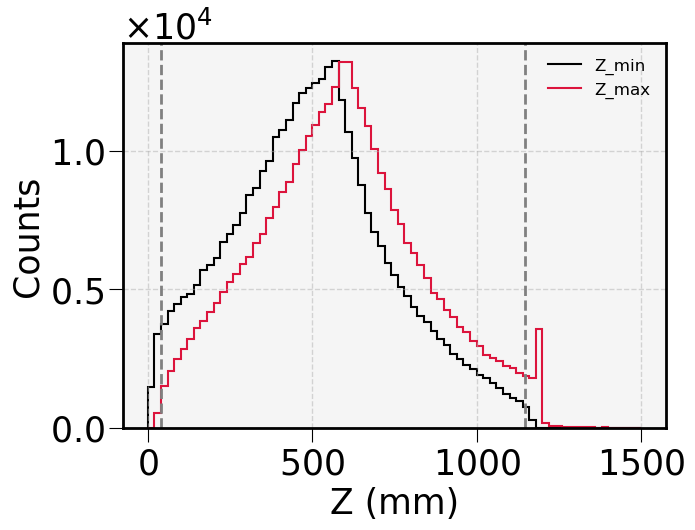

In [7]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
_, Z_edges = np.histogram(EVENT_DF['Z_bary'], bins=n_bins, range=(0, 1500))

for i, var in enumerate(['Z_min', 'Z_max']):

        Z_counts, _ = np.histogram(EVENT_DF[var], bins=Z_edges)

        # ----- Plotting ----- #
        plt.stairs(Z_counts, Z_edges, label=f'{var}',
                   fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Z-limits
plt.axvline(x=Z_LOW, c='grey', ls='--')
plt.axvline(x=Z_UP, c='grey', ls='--')
        
# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper right', fontsize=12, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

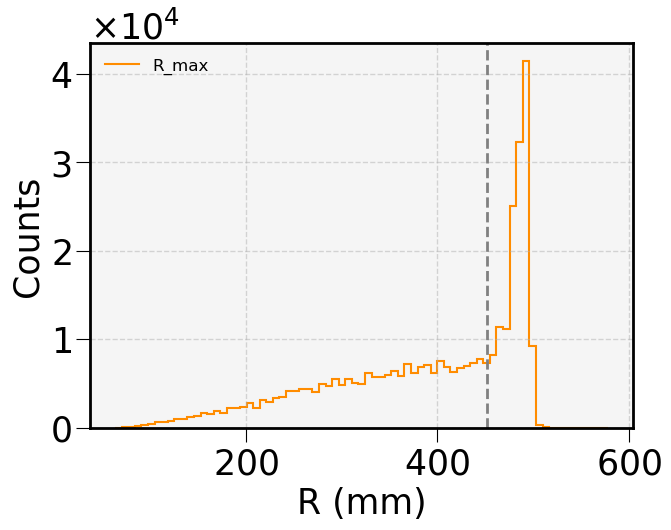

In [8]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

R_counts, R_edges = np.histogram(EVENT_DF['R_max'], bins=n_bins)
# ----- Plotting ----- #
plt.stairs(R_counts, R_edges, label='R_max',
           fill=False, lw=1.5, ec=crudo.pt.hist_colors[2])

# R-limit
plt.axvline(x=R_UP, c='grey', ls='--')
        
# ----- Styling ----- #
plt.xlabel('R (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper left', fontsize=12, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

## Fiducial Volume

In [9]:
fiducial_mask = (EVENT_DF['region'] == 'fiducial')
FIDU_EVT_DF = EVENT_DF[fiducial_mask].copy()
FIDU_EVT_DF

,event,global_event,time,run_number,particle,region,nS1,nS2,n_cluster,old_n_hits,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
9,120,4,1.751990e+09,15589,electron,fiducial,1,1,3,1365,...,335.559998,446.578680,675.0,56.735172,790500.0,347422.250000,325.700,5438.912598,1457495.875,104431.320312
22,400,12,1.751990e+09,15589,electron,fiducial,1,1,1,1030,...,246.178909,257.668071,625.0,40.804302,188000.0,200394.265625,427.250,4814.290527,1415495.125,92607.203125
23,442,13,1.751990e+09,15589,electron,fiducial,1,1,2,258,...,74.863655,89.218164,525.0,13.394168,497525.0,67065.500000,216.350,3785.974609,1405486.250,37907.949219
34,687,20,1.751990e+09,15589,electron,fiducial,1,1,1,1370,...,342.572662,430.953229,725.0,60.658051,624925.0,339142.000000,269.350,5351.426270,1411479.500,90060.789062
38,729,22,1.751990e+09,15589,electron,fiducial,1,1,1,616,...,201.999344,214.075911,825.0,31.553558,210475.0,142254.812500,197.800,3983.655762,1405485.875,46304.746094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445049,3846990,792273,1.752077e+09,15589,electron,fiducial,1,1,1,1804,...,443.319672,533.398742,700.0,80.077065,525475.0,366544.718750,317.525,5292.683105,1411497.250,100983.171875
1445050,3847018,792274,1.752077e+09,15589,electron,fiducial,1,1,1,248,...,72.906906,114.410682,300.0,13.777174,1054150.0,83268.867188,131.025,6003.708496,1407491.750,28278.976562
1445053,3847116,792276,1.752077e+09,15589,electron,fiducial,1,1,1,243,...,63.984344,94.264270,375.0,9.797277,944025.0,70154.390625,131.000,4242.674316,1411488.000,26688.017578
1445054,3847130,792277,1.752077e+09,15589,electron,fiducial,1,1,1,300,...,95.319832,124.423254,300.0,18.348984,701125.0,84164.617188,222.225,5103.366699,1408485.000,43307.468750


# Energy Analysis

How does the energy look?

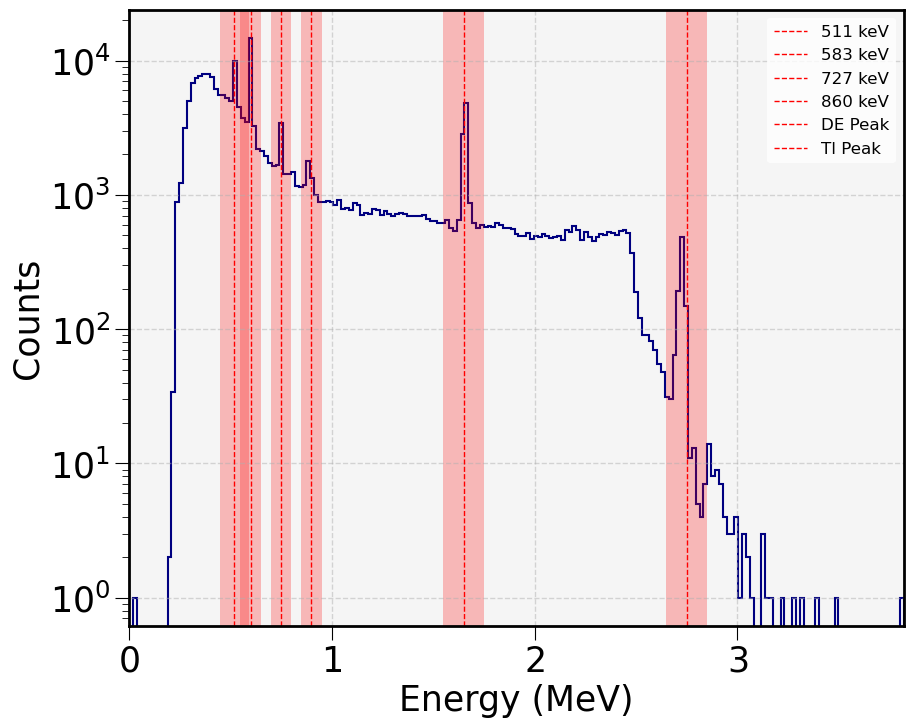

In [10]:
# First, we check which energy column is in the dataframe
if 'E_evt_pe' in FIDU_EVT_DF.columns:
    ENERGY_UNITS, ENERGY_COL = 'PE', 'E_evt_pe'
    KNOWN_PEAKS = KNOWN_PEAKS_PES
elif 'E_evt' in FIDU_EVT_DF.columns:
    ENERGY_UNITS, ENERGY_COL = 'MeV', 'E_evt'
    KNOWN_PEAKS = KNOWN_PEAKS_MEV

# ----- Plotting ----- #
n_bins = 200

E_counts, E_edges = np.histogram(FIDU_EVT_DF[ENERGY_COL], bins=n_bins)

plt.stairs(E_counts, E_edges,
           fill=False, lw=1.5, ec=crudo.pt.hist_colors[5])

# Reference peaks
for peak_name, peak_info in KNOWN_PEAKS.items():
    plt.axvline(x=peak_info['guess'], c='red', ls='--', lw=1.0, label=peak_name)
    plt.axvspan(peak_info['range'][0], peak_info['range'][1], color='red', ec=None, alpha=0.25)
        
# ----- Styling ----- #
plt.xlabel(f'Energy ({ENERGY_UNITS})')
plt.xlim(0, E_edges[-1])
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3) if ENERGY_UNITS == 'PE' else (0, 0))
plt.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Execution


==================== RUNNING MeV → MeV CALIBRATION ====================

STAGE 01: Fitting uncalibrated peaks to find positions...


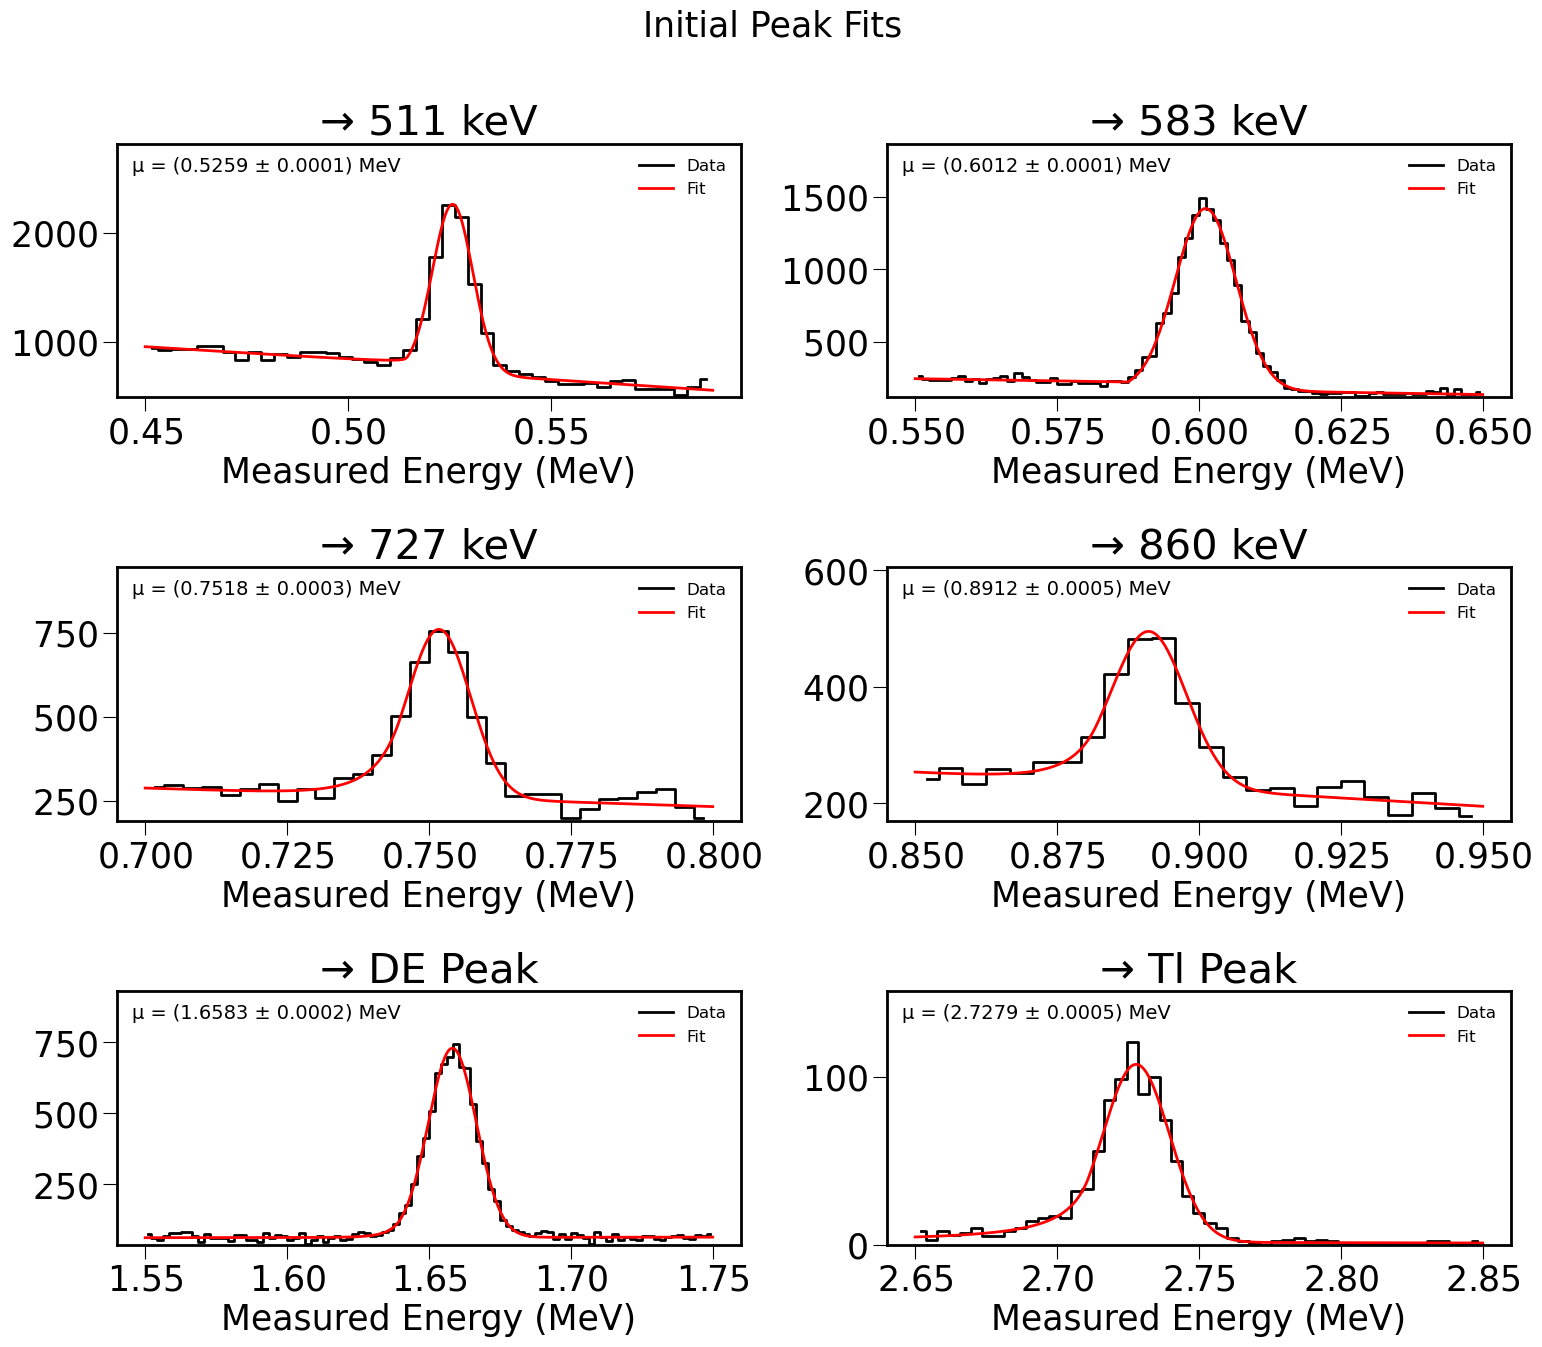


Stage 02: Calibration → Calibrated Energy (MeV) = 9.55e-01 * Uncalib. Energy (MeV) + 0.0086


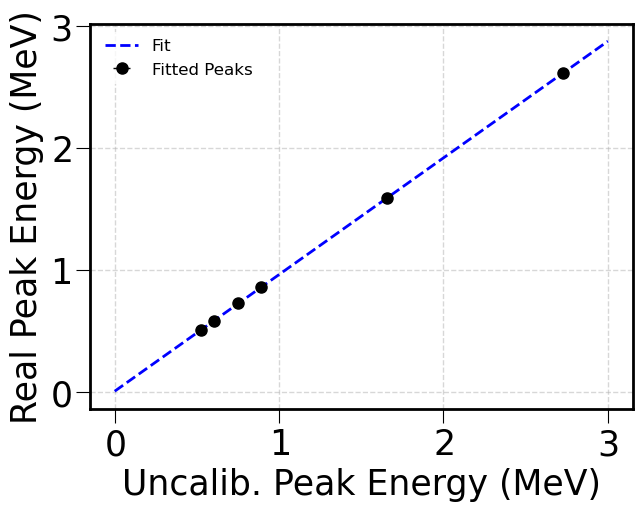


Stage 03: Applying calibration, going from MeV to MeV...

Stage 04: Computing final energy resolution...


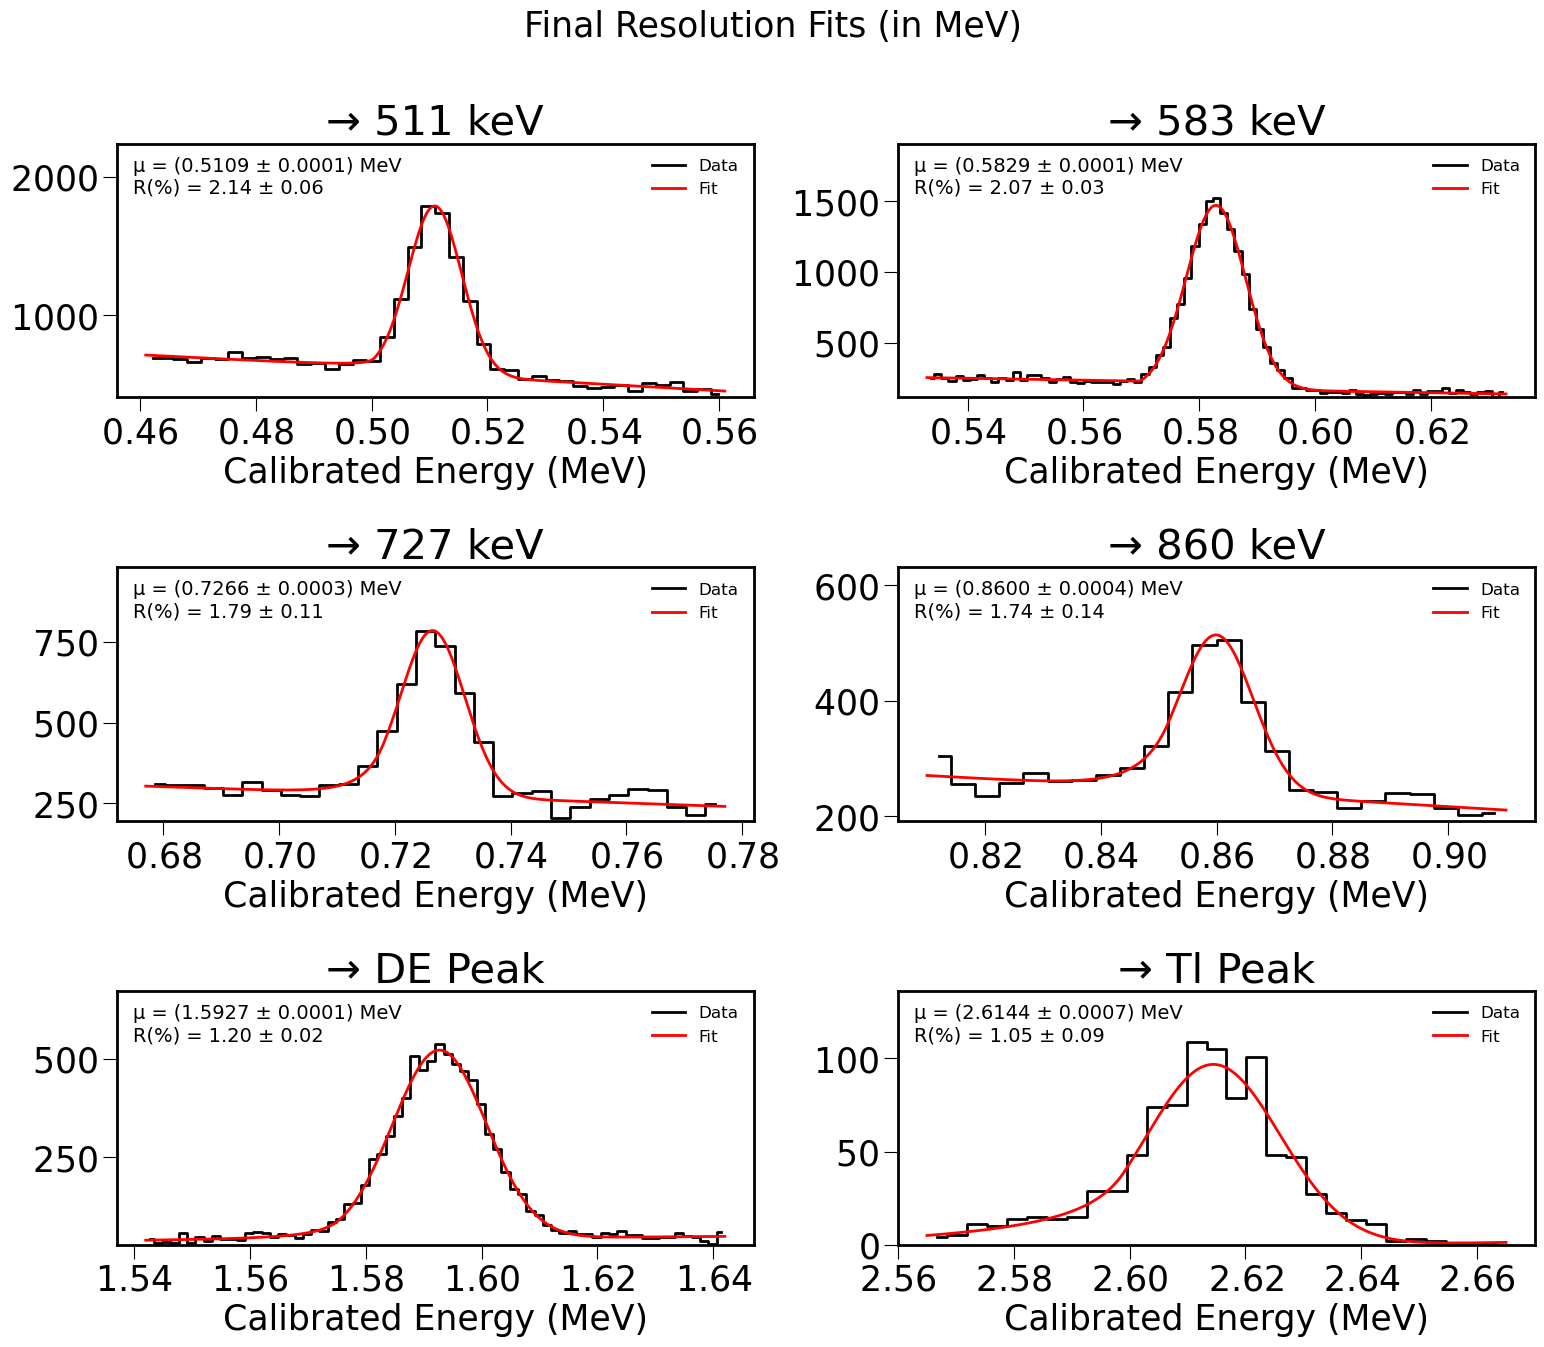

----- Final Summary -----

Calibration Results:
       m_cv     m_err      b_cv     b_err  r_value
0  0.955348  0.000233  0.008559  0.000332      1.0


Energy Resolution Results:
      peak  resolution_(FWHM)  resolution_error
0  511 keV           2.136723          0.056321
1  583 keV           2.068731          0.031228
2  727 keV           1.792703          0.111661
3  860 keV           1.743206          0.135706
4  DE Peak           1.201865          0.022241
5  Tl Peak           1.047054          0.086015


In [11]:
calibration_table, resolution_table = calibrate_and_get_resolution( event_df     = FIDU_EVT_DF
                                                                  , known_peaks  = KNOWN_PEAKS
                                                                  , energy_col   = ENERGY_COL
                                                                  , energy_units = ENERGY_UNITS )

print("----- Final Summary -----")
print("\nCalibration Results:")
print(calibration_table)
print(f"\n{'='*50}\n")
print("Energy Resolution Results:")
print(resolution_table)